# Vecchia Lag-2 Fixed-Budget Reallocation

Question: after fixing the current-time base neighborhood and the lag-1 structure, is an additional conditioning slot more useful at `t-2`, or as an extra current-time spatial neighbor?

This follows the ratio baseline idea:

```text
x = 8
rho_1 = 3/4 -> m_1 = 6
rho_2 candidates vary
```

Fixed budget design:

```text
Reference total budget = t:8 + (t-1 same loc + 6) + (t-2 same loc + 6) = 22

Realloc_Ck:
t   : 8 + (6-k) nearest spatial neighbors
t-1 : same location + 6 same-neighborhood neighbors
t-2 : same location + k same-neighborhood neighbors
total = [8 + (6-k)] + [1+6] + [1+k] = 22
```

This is the fair test for whether `t-2` local-neighborhood slots are more valuable than extra current-time spatial slots.


In [1]:
import os
import sys
import time
import io
import contextlib
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.fft
import matplotlib.pyplot as plt

AMAREL_SRC = "/home/jl2815/tco"
LOCAL_SRC = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
_src = AMAREL_SRC if os.path.exists(AMAREL_SRC) else LOCAL_SRC
sys.path.insert(0, _src)

from GEMS_TCO import kernels_vecchia
from GEMS_TCO import orderings as _orderings

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
DELTA_LAT = 0.044
DELTA_LON = 0.063
T_STEPS = 8

print("DEVICE:", DEVICE)
print("SRC:", _src)
print("Grid resolution:", DELTA_LAT, DELTA_LON)


DEVICE: cpu
SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
Grid resolution: 0.044 0.063


## Settings

Defaults use the full spatial range and a short first-stage Monte Carlo. Use the focused section for a longer run after seeing the curve.


In [2]:
LAT_RANGE = (-3.0, 2.0)
LON_RANGE = (121.0, 131.0)
MC_NUM_ITERS = 10
SEED = 42

SMOOTH = 0.5
MM_COND_NUMBER = 100
NHEADS = 0

CURRENT_NEIGHBORS_X = 8
LAG1_RETENTION_RATIO = 0.75
MAX_LAG2_NEIGHBORS = 6
REALLOC_C_VALUES = [0, 1, 2, 3, 4, 5, 6]
DAILY_STRIDE = 2
RETENTION_ROUNDING = "round"

LBFGS_STEPS = 5
LBFGS_EVAL = 20
LBFGS_HIST = 10
INIT_NOISE = 0.7
SUPPRESS_FIT_PRINTS = True

RUN_ONE_SHOT_GODAMBE = True
HESSIAN_EPS = 1e-4
SCORE_EPS = 1e-5
H_RIDGE_SCALE = 1e-6
GODAMBE_J_METHOD = "block"
GODAMBE_BLOCK_LAT_WIDTH = 0.50
GODAMBE_BLOCK_LON_WIDTH = 0.50
GODAMBE_BLOCK_TIME_WIDTH = 2.0

TRUE_DICT = {
    "sigmasq": 10.0,
    "range_lat": 0.30,
    "range_lon": 0.40,
    "range_time": 2.0,
    "advec_lat": 0.08,
    "advec_lon": -0.126,
    "nugget": 2.5,
}

def ratio_to_count(x, ratio, method=RETENTION_ROUNDING):
    raw = x * ratio
    if method == "round":
        val = int(np.round(raw))
    elif method == "floor":
        val = int(np.floor(raw))
    elif method == "ceil":
        val = int(np.ceil(raw))
    else:
        raise ValueError(f"Unknown rounding method: {method}")
    return max(0, min(int(x), val))

BASE_LIMIT_A = CURRENT_NEIGHBORS_X
FIXED_LIMIT_B = ratio_to_count(CURRENT_NEIGHBORS_X, LAG1_RETENTION_RATIO)
REFERENCE_TOTAL = BASE_LIMIT_A + (1 + FIXED_LIMIT_B) + (1 + MAX_LAG2_NEIGHBORS)

# Ratio-reference values for interpretation.
RATIO_BASELINE_C_QUARTER = ratio_to_count(CURRENT_NEIGHBORS_X, 0.25)
RATIO_BASELINE_C_HALF = ratio_to_count(CURRENT_NEIGHBORS_X, 0.50)

def make_lag2_realloc_specs(c_values):
    specs = {}
    for c in c_values:
        extra_current = MAX_LAG2_NEIGHBORS - c
        limit_A = BASE_LIMIT_A + extra_current
        suffix = ""
        if c == RATIO_BASELINE_C_QUARTER:
            suffix = "_QuarterBase"
        elif c == RATIO_BASELINE_C_HALF:
            suffix = "_HalfBase"
        name = f"Realloc_C{c:02d}_A{limit_A:02d}{suffix}"
        specs[name] = {
            "lag2_nbs": c,
            "extra_current_nbs": extra_current,
            "limit_A": limit_A,
            "limit_B": FIXED_LIMIT_B,
            "limit_C": c,
            "lag1_ratio": FIXED_LIMIT_B / BASE_LIMIT_A,
            "lag2_ratio": c / BASE_LIMIT_A,
            "is_quarter_baseline": c == RATIO_BASELINE_C_QUARTER,
            "is_half_baseline": c == RATIO_BASELINE_C_HALF,
            "total_conditioning": limit_A + (1 + FIXED_LIMIT_B) + (1 + c),
            "description": f"t: {limit_A}; t-1: same loc + {FIXED_LIMIT_B}; t-2: same loc + {c}",
        }
    return specs

print(f"Fixed budget: reference total={REFERENCE_TOTAL}; B={FIXED_LIMIT_B}; quarter C={RATIO_BASELINE_C_QUARTER}; half C={RATIO_BASELINE_C_HALF}")
MODEL_SPECS = make_lag2_realloc_specs(REALLOC_C_VALUES)
pd.DataFrame(MODEL_SPECS).T


Fixed budget: reference total=22; B=6; quarter C=2; half C=4


,lag2_nbs,extra_current_nbs,limit_A,limit_B,limit_C,lag1_ratio,lag2_ratio,is_quarter_baseline,is_half_baseline,total_conditioning,description
Realloc_C00_A14,0,6,14,6,0,0.75,0.0,False,False,22,t: 14; t-1: same loc + 6; t-2: same loc + 0
Realloc_C01_A13,1,5,13,6,1,0.75,0.125,False,False,22,t: 13; t-1: same loc + 6; t-2: same loc + 1
Realloc_C02_A12_QuarterBase,2,4,12,6,2,0.75,0.25,True,False,22,t: 12; t-1: same loc + 6; t-2: same loc + 2
Realloc_C03_A11,3,3,11,6,3,0.75,0.375,False,False,22,t: 11; t-1: same loc + 6; t-2: same loc + 3
Realloc_C04_A10_HalfBase,4,2,10,6,4,0.75,0.5,False,True,22,t: 10; t-1: same loc + 6; t-2: same loc + 4
Realloc_C05_A09,5,1,9,6,5,0.75,0.625,False,False,22,t: 9; t-1: same loc + 6; t-2: same loc + 5
Realloc_C06_A08,6,0,8,6,6,0.75,0.75,False,False,22,t: 8; t-1: same loc + 6; t-2: same loc + 6


## Simulation Helpers

Within each Monte Carlo iteration, all `t-2` choices use the same simulated field and same initialization.


In [3]:
P_LABELS = ["sigmasq", "range_lat", "range_lon", "range_time", "advec_lat", "advec_lon", "nugget"]
P_COLS = ["sigmasq_est", "range_lat_est", "range_lon_est", "range_t_est", "advec_lat_est", "advec_lon_est", "nugget_est"]
SPATIAL_KEYS = ["sigmasq", "range_lat", "range_lon"]
ADVECTION_KEYS = ["advec_lat", "advec_lon"]

def transform_log_phi_to_physical(p):
    phi1, phi2, phi3, phi4 = (torch.exp(p[i]) for i in range(4))
    rlon = 1.0 / phi2
    return torch.stack([
        phi1 / phi2,
        rlon / torch.sqrt(phi3),
        rlon,
        rlon / torch.sqrt(phi4),
        p[4],
        p[5],
        torch.exp(p[6]),
    ])

def get_covariance_on_grid(lx, ly, lt, params):
    params = torch.clamp(params, min=-15.0, max=15.0)
    phi1, phi2, phi3, phi4 = (torch.exp(params[i]) for i in range(4))
    u_lat = lx - params[4] * lt
    u_lon = ly - params[5] * lt
    dist = torch.sqrt(u_lat.pow(2) * phi3 + u_lon.pow(2) + lt.pow(2) * phi4 + 1e-8)
    return (phi1 / phi2) * torch.exp(-dist * phi2)

def build_target_grid(lat_range, lon_range):
    lat0, lat1 = float(min(lat_range)), float(max(lat_range))
    lon0, lon1 = float(min(lon_range)), float(max(lon_range))
    n_lat = int(np.floor((lat1 - lat0) / DELTA_LAT + 1e-9)) + 1
    n_lon = int(np.floor((lon1 - lon0) / DELTA_LON + 1e-9)) + 1
    lats = lat0 + torch.arange(n_lat, device=DEVICE, dtype=DTYPE) * DELTA_LAT
    lons = lon0 + torch.arange(n_lon, device=DEVICE, dtype=DTYPE) * DELTA_LON
    lats = torch.round(lats * 10000) / 10000
    lons = torch.round(lons * 10000) / 10000
    g_lat, g_lon = torch.meshgrid(lats, lons, indexing="ij")
    grid_coords = torch.stack([g_lat.flatten(), g_lon.flatten()], dim=1)
    return lats, lons, grid_coords

def grid_resolution_report(lats, lons):
    lat_d = torch.diff(lats).detach().cpu().numpy()
    lon_d = torch.diff(lons).detach().cpu().numpy()
    return {
        "lat_min_step": float(lat_d.min()) if len(lat_d) else np.nan,
        "lat_max_step": float(lat_d.max()) if len(lat_d) else np.nan,
        "lon_min_step": float(lon_d.min()) if len(lon_d) else np.nan,
        "lon_max_step": float(lon_d.max()) if len(lon_d) else np.nan,
        "lat_first_last": (float(lats[0]), float(lats[-1])),
        "lon_first_last": (float(lons[0]), float(lons[-1])),
    }

def generate_field_values(n_lat, n_lon, t_steps, params):
    cpu = torch.device("cpu")
    f32 = torch.float32
    px, py, pt = 2 * n_lat, 2 * n_lon, 2 * t_steps
    lx = torch.arange(px, device=cpu, dtype=f32) * DELTA_LAT
    lx[px // 2:] -= px * DELTA_LAT
    ly = torch.arange(py, device=cpu, dtype=f32) * DELTA_LON
    ly[py // 2:] -= py * DELTA_LON
    lt = torch.arange(pt, device=cpu, dtype=f32)
    lt[pt // 2:] -= pt
    params_cpu = params.cpu().float()
    Lx, Ly, Lt = torch.meshgrid(lx, ly, lt, indexing="ij")
    C = get_covariance_on_grid(Lx, Ly, Lt, params_cpu)
    S = torch.fft.fftn(C)
    S.real = torch.clamp(S.real, min=0)
    noise = torch.fft.fftn(torch.randn(px, py, pt, device=cpu, dtype=f32))
    field = torch.fft.ifftn(torch.sqrt(S.real) * noise).real[:n_lat, :n_lon, :t_steps]
    return field.to(device=DEVICE, dtype=DTYPE)

def assemble_reg_map(field, grid_coords, true_params, t_offset=21.0):
    nugget_std = torch.sqrt(torch.exp(true_params[6]))
    n_grid = grid_coords.shape[0]
    field_flat = field.reshape(n_grid, field.shape[-1])
    reg_map = {}
    for t_idx in range(field.shape[-1]):
        key = f"t{t_idx}"
        t_val = float(t_offset + t_idx)
        dummy = torch.zeros(7, device=DEVICE, dtype=DTYPE)
        if t_idx > 0:
            dummy[t_idx - 1] = 1.0
        rows = torch.zeros((n_grid, 11), device=DEVICE, dtype=DTYPE)
        rows[:, :2] = grid_coords
        rows[:, 2] = field_flat[:, t_idx] + torch.randn(n_grid, device=DEVICE, dtype=DTYPE) * nugget_std
        rows[:, 3] = t_val
        rows[:, 4:] = dummy.unsqueeze(0).expand(n_grid, -1)
        reg_map[key] = rows.detach()
    return reg_map

def compute_grid_ordering(grid_coords, mm_cond_number):
    coords_np = grid_coords.detach().cpu().numpy()
    ord_mm = _orderings.maxmin_cpp(coords_np)
    nns = _orderings.find_nns_l2(locs=coords_np[ord_mm], max_nn=mm_cond_number)
    return ord_mm, nns

def true_to_log_params(true_dict):
    phi2 = 1.0 / true_dict["range_lon"]
    phi1 = true_dict["sigmasq"] * phi2
    phi3 = (true_dict["range_lon"] / true_dict["range_lat"]) ** 2
    phi4 = (true_dict["range_lon"] / true_dict["range_time"]) ** 2
    return [np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4), true_dict["advec_lat"], true_dict["advec_lon"], np.log(true_dict["nugget"])]

def backmap_params(out_params):
    p = [x.item() if isinstance(x, torch.Tensor) else float(x) for x in out_params[:7]]
    phi2 = np.exp(p[1])
    phi3 = np.exp(p[2])
    phi4 = np.exp(p[3])
    rlon = 1.0 / phi2
    return {
        "sigmasq": np.exp(p[0]) / phi2,
        "range_lat": rlon / phi3 ** 0.5,
        "range_lon": rlon,
        "range_time": rlon / phi4 ** 0.5,
        "advec_lat": p[4],
        "advec_lon": p[5],
        "nugget": np.exp(p[6]),
    }

def rmsre_for_keys(est, true_dict, keys, zero_thresh=0.01):
    vals = []
    for key in keys:
        tv = true_dict[key]
        ev = est[key]
        if abs(tv) >= zero_thresh:
            vals.append(((ev - tv) / abs(tv)) ** 2)
        else:
            vals.append(abs(ev - tv) ** 2)
    return float(np.sqrt(np.mean(vals)))

def relative_se_summary(se_by_key, denom_dict, keys, zero_thresh=0.01):
    vals = []
    for key in keys:
        denom = abs(denom_dict[key])
        if denom >= zero_thresh:
            vals.append((se_by_key[key] / denom) ** 2)
        else:
            vals.append(se_by_key[key] ** 2)
    return float(np.sqrt(np.mean(vals)))

def calculate_metrics(out_params, true_dict):
    est = backmap_params(out_params)
    return {
        "overall_rmsre": rmsre_for_keys(est, true_dict, P_LABELS),
        "spatial_rmsre": rmsre_for_keys(est, true_dict, SPATIAL_KEYS),
        "range_time_re": abs(est["range_time"] - true_dict["range_time"]) / abs(true_dict["range_time"]),
        "advec_rmsre": rmsre_for_keys(est, true_dict, ADVECTION_KEYS),
        "nugget_re": abs(est["nugget"] - true_dict["nugget"]) / abs(true_dict["nugget"]),
        "est": est,
    }

def make_random_init(rng, true_log, init_noise):
    noisy = list(true_log)
    for i in [0, 1, 2, 3, 6]:
        noisy[i] = true_log[i] + rng.uniform(-init_noise, init_noise)
    for i in [4, 5]:
        scale = max(abs(true_log[i]), 0.05)
        noisy[i] = true_log[i] + rng.uniform(-2 * scale, 2 * scale)
    return noisy


## Optional Godambe Helpers

The Godambe section uses block/cluster scores. This is diagnostic; Monte Carlo realized recovery is the main finite-sample evidence.


In [4]:
def finite_diff_hessian(nll_fn, p, eps=HESSIAN_EPS):
    n = p.shape[0]
    H = torch.zeros(n, n, device=p.device, dtype=p.dtype)
    for i in range(n):
        p_p = p.detach().clone(); p_m = p.detach().clone()
        p_p[i] += eps; p_m[i] -= eps
        p_p.requires_grad_(True); p_m.requires_grad_(True)
        g_p = torch.autograd.grad(nll_fn(p_p), p_p)[0].detach()
        g_m = torch.autograd.grad(nll_fn(p_m), p_m)[0].detach()
        H[i] = (g_p - g_m) / (2.0 * eps)
    return (H + H.T) / 2.0

def vecchia_per_unit_target_coords(model):
    chunks = []
    if model.Heads_data is not None and model.Heads_data.shape[0] > 0:
        chunks.append(model.Heads_data[:, [0, 1, 3]].to(dtype=DTYPE))
    for X_b in [model.X_A, model.X_AB, model.X_ABC]:
        if X_b is not None and X_b.shape[0] > 0:
            chunks.append(X_b[:, -1, :].to(dtype=DTYPE))
    if not chunks:
        return torch.empty((0, 3), device=DEVICE, dtype=DTYPE)
    return torch.cat(chunks, dim=0)

def make_block_ids(target_coords):
    lat = target_coords[:, 0]
    lon = target_coords[:, 1]
    tim = target_coords[:, 2]
    lat_id = torch.floor((lat - lat.min()) / GODAMBE_BLOCK_LAT_WIDTH).to(torch.long)
    lon_id = torch.floor((lon - lon.min()) / GODAMBE_BLOCK_LON_WIDTH).to(torch.long)
    if GODAMBE_BLOCK_TIME_WIDTH is None or GODAMBE_BLOCK_TIME_WIDTH <= 0:
        time_id = torch.zeros_like(lat_id)
    else:
        time_id = torch.floor((tim - tim.min()) / GODAMBE_BLOCK_TIME_WIDTH).to(torch.long)
    n_lon = int(lon_id.max().item()) + 1 if lon_id.numel() else 1
    n_time = int(time_id.max().item()) + 1 if time_id.numel() else 1
    raw_id = (lat_id * n_lon + lon_id) * n_time + time_id
    _, block_id = torch.unique(raw_id, sorted=True, return_inverse=True)
    return block_id

def score_cov_per_unit_centered(score_mat):
    n_units = score_mat.shape[1]
    score_mean = score_mat.mean(dim=1)
    score_centered = score_mat - score_mean.unsqueeze(1)
    if n_units > 1:
        return score_centered @ score_centered.T / (n_units * (n_units - 1))
    return score_mat @ score_mat.T / max(n_units ** 2, 1)

def score_cov_block_cluster(score_mat, target_coords):
    n_units = score_mat.shape[1]
    scores = score_mat.T.contiguous()
    block_id = make_block_ids(target_coords)
    n_blocks = int(block_id.max().item()) + 1 if block_id.numel() else 0
    block_scores = torch.zeros((n_blocks, scores.shape[1]), device=DEVICE, dtype=DTYPE)
    block_scores.index_add_(0, block_id, scores)
    if n_blocks > 1:
        centered = block_scores - block_scores.mean(dim=0, keepdim=True)
        J = centered.T @ centered * (n_blocks / (n_blocks - 1)) / (n_units ** 2)
    else:
        J = block_scores.T @ block_scores / max(n_units ** 2, 1)
    return J, n_blocks

def compute_vecchia_godambe(model, raw_params):
    p_hat = torch.tensor(raw_params[:7], device=DEVICE, dtype=DTYPE, requires_grad=True)

    def nll(p):
        return model.vecchia_batched_likelihood(p)

    H = finite_diff_hessian(nll, p_hat)
    eig = torch.linalg.eigvalsh(H).detach()
    h_abs_min = torch.clamp(torch.min(torch.abs(eig)), min=1e-12)
    h_cond = float((torch.max(torch.abs(eig)) / h_abs_min).detach().cpu())
    beta_hat = model.get_gls_beta(p_hat).detach()

    def per_unit_losses(p):
        return model.vecchia_per_unit_nll_terms(p, beta_hat)

    cols = []
    for k in range(p_hat.shape[0]):
        pp = p_hat.detach().clone(); pm = p_hat.detach().clone()
        pp[k] += SCORE_EPS; pm[k] -= SCORE_EPS
        with torch.no_grad():
            cols.append((per_unit_losses(pp) - per_unit_losses(pm)) / (2.0 * SCORE_EPS))
    score_mat = torch.stack(cols)
    n_units = score_mat.shape[1]
    target_coords = vecchia_per_unit_target_coords(model)
    if target_coords.shape[0] != n_units:
        raise RuntimeError(f"target/score mismatch: targets={target_coords.shape[0]}, scores={n_units}")

    score_mean = score_mat.mean(dim=1)
    p_grad = p_hat.detach().clone().requires_grad_(True)
    profile_grad = torch.autograd.grad(nll(p_grad), p_grad)[0].detach()
    score_grad_diff = profile_grad - score_mean

    J_uncentered = score_mat @ score_mat.T / (n_units ** 2)
    J_centered = score_cov_per_unit_centered(score_mat)
    J_block, n_blocks = score_cov_block_cluster(score_mat, target_coords)
    if GODAMBE_J_METHOD == "block":
        J_main = J_block
    elif GODAMBE_J_METHOD == "per_unit_centered":
        J_main = J_centered
    elif GODAMBE_J_METHOD == "per_unit_uncentered":
        J_main = J_uncentered
    else:
        raise ValueError(f"Unknown GODAMBE_J_METHOD={GODAMBE_J_METHOD!r}")

    eye = torch.eye(H.shape[0], device=DEVICE, dtype=DTYPE)
    h_scale = torch.clamp(torch.mean(torch.abs(torch.diag(H))), min=1.0)
    H_inv = torch.linalg.pinv(H + eye * h_scale * H_RIDGE_SCALE)
    Jac = torch.autograd.functional.jacobian(transform_log_phi_to_physical, p_hat)

    def summarize_J(J):
        G_raw = H_inv @ J @ H_inv
        G_phys = Jac @ G_raw @ Jac.T
        se = torch.sqrt(torch.clamp(torch.diag(G_phys), min=0.0)).detach().cpu().numpy()
        se_by_key = dict(zip(P_LABELS, [float(x) for x in se]))
        return se_by_key, {
            "spatial": relative_se_summary(se_by_key, TRUE_DICT, SPATIAL_KEYS),
            "overall": relative_se_summary(se_by_key, TRUE_DICT, P_LABELS),
            "advec": relative_se_summary(se_by_key, TRUE_DICT, ADVECTION_KEYS),
            "nugget": se_by_key["nugget"] / abs(TRUE_DICT["nugget"]),
        }

    se_main, rel_main = summarize_J(J_main)
    se_block, rel_block = summarize_J(J_block)
    se_centered, rel_centered = summarize_J(J_centered)
    se_uncentered, rel_uncentered = summarize_J(J_uncentered)
    return {
        "gim_j_method": GODAMBE_J_METHOD,
        "gim_n_units": int(n_units),
        "gim_n_blocks": int(n_blocks),
        "gim_h_cond_abs": h_cond,
        "gim_score_mean_max_abs": float(torch.max(torch.abs(score_mean)).detach().cpu()),
        "gim_profile_grad_max_abs": float(torch.max(torch.abs(profile_grad)).detach().cpu()),
        "gim_score_profile_diff_max_abs": float(torch.max(torch.abs(score_grad_diff)).detach().cpu()),
        "gim_spatial_rel_se": rel_main["spatial"],
        "gim_overall_rel_se": rel_main["overall"],
        "gim_advec_rel_se": rel_main["advec"],
        "gim_nugget_rel_se": rel_main["nugget"],
        "gim_spatial_rel_se_block": rel_block["spatial"],
        "gim_spatial_rel_se_perunit_centered": rel_centered["spatial"],
        "gim_spatial_rel_se_uncentered": rel_uncentered["spatial"],
        **{f"gim_se_{k}": v for k, v in se_main.items()},
    }


## Fit And Monte Carlo


In [5]:
def fit_vecchia_spec(model_name, spec, reg_map_ord, nns_grid, initial_vals, compute_godambe=False):
    params = [torch.tensor([val], device=DEVICE, dtype=DTYPE, requires_grad=True) for val in initial_vals]
    model = kernels_vecchia.fit_vecchia_lbfgs(
        smooth=SMOOTH,
        input_map=reg_map_ord,
        nns_map=nns_grid,
        mm_cond_number=MM_COND_NUMBER,
        nheads=NHEADS,
        limit_A=spec["limit_A"],
        limit_B=spec["limit_B"],
        limit_C=spec["limit_C"],
        daily_stride=DAILY_STRIDE,
    )
    t0 = time.time()
    if SUPPRESS_FIT_PRINTS:
        with contextlib.redirect_stdout(io.StringIO()):
            model.precompute_conditioning_sets()
    else:
        model.precompute_conditioning_sets()
    precompute_s = time.time() - t0

    optimizer = model.set_optimizer(params, lr=1.0, max_iter=LBFGS_EVAL, history_size=LBFGS_HIST)
    t1 = time.time()
    if SUPPRESS_FIT_PRINTS:
        with contextlib.redirect_stdout(io.StringIO()):
            out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    else:
        out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    fit_s = time.time() - t1

    metrics = calculate_metrics(out, TRUE_DICT)
    godambe = {}
    gim_s = 0.0
    if compute_godambe:
        t2 = time.time()
        godambe = compute_vecchia_godambe(model, [float(x) for x in out[:7]])
        gim_s = time.time() - t2
    return out, float(out[-1]), int(n_iter), precompute_s, fit_s, gim_s, metrics, godambe

def run_experiment(num_iters=MC_NUM_ITERS, seed=SEED, compute_godambe=False, save_csv=True, csv_name=None):
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    true_log = true_to_log_params(TRUE_DICT)
    true_params = torch.tensor(true_log, device=DEVICE, dtype=DTYPE)
    lats_grid, lons_grid, grid_coords = build_target_grid(LAT_RANGE, LON_RANGE)
    n_lat, n_lon = len(lats_grid), len(lons_grid)
    print(f"Grid: {n_lat} x {n_lon} x {T_STEPS} = {n_lat * n_lon * T_STEPS:,} rows")
    print("Actual resolution:", grid_resolution_report(lats_grid, lons_grid))
    print("Model specs:")
    display(pd.DataFrame(MODEL_SPECS).T[["limit_A", "limit_B", "limit_C", "extra_current_nbs", "lag1_ratio", "lag2_ratio", "is_quarter_baseline", "is_half_baseline", "total_conditioning", "description"]])
    ord_grid, nns_grid = compute_grid_ordering(grid_coords, MM_COND_NUMBER)
    print("Ordering done")

    records = []
    for it in range(num_iters):
        print(f"\n=== Iteration {it + 1}/{num_iters} ===")
        initial_vals = make_random_init(rng, true_log, INIT_NOISE)
        field = generate_field_values(n_lat, n_lon, T_STEPS, true_params)
        reg_map = assemble_reg_map(field, grid_coords, true_params)
        del field
        reg_map_ord = {k: v[ord_grid] for k, v in reg_map.items()}
        for model_name, spec in MODEL_SPECS.items():
            try:
                print(f"{model_name}: fitting", end="")
                out, loss, n_iter, pre_s, fit_s, gim_s, metrics, godambe = fit_vecchia_spec(
                    model_name, spec, reg_map_ord, nns_grid, initial_vals, compute_godambe=compute_godambe
                )
                est = metrics.pop("est")
                row = {
                    "iter": it + 1,
                    "model": model_name,
                    "lag2_nbs": spec["lag2_nbs"],
                    "limit_A": spec["limit_A"],
                    "limit_B": spec["limit_B"],
                    "limit_C": spec["limit_C"],
                    "extra_current_nbs": spec["extra_current_nbs"],
                    "lag1_ratio": spec["lag1_ratio"],
                    "lag2_ratio": spec["lag2_ratio"],
                    "is_quarter_baseline": spec["is_quarter_baseline"],
                    "is_half_baseline": spec["is_half_baseline"],
                    "total_conditioning": spec["total_conditioning"],
                    "loss": round(loss, 6),
                    "overall_rmsre": round(metrics["overall_rmsre"], 6),
                    "spatial_rmsre": round(metrics["spatial_rmsre"], 6),
                    "range_time_re": round(metrics["range_time_re"], 6),
                    "advec_rmsre": round(metrics["advec_rmsre"], 6),
                    "nugget_re": round(metrics["nugget_re"], 6),
                    "precompute_s": round(pre_s, 3),
                    "fit_s": round(fit_s, 3),
                    "gim_s": round(gim_s, 3),
                    "total_s": round(pre_s + fit_s + gim_s, 3),
                    "fit_iter": n_iter,
                }
                row.update({
                    "sigmasq_est": round(est["sigmasq"], 6),
                    "range_lat_est": round(est["range_lat"], 6),
                    "range_lon_est": round(est["range_lon"], 6),
                    "range_t_est": round(est["range_time"], 6),
                    "advec_lat_est": round(est["advec_lat"], 6),
                    "advec_lon_est": round(est["advec_lon"], 6),
                    "nugget_est": round(est["nugget"], 6),
                })
                row.update({k: round(v, 8) if isinstance(v, float) else v for k, v in godambe.items()})
                records.append(row)
                print(f" | loss={loss:.4f} spatial={row['spatial_rmsre']:.4f} overall={row['overall_rmsre']:.4f} time={row['total_s']:.1f}s")
            except Exception as e:
                print(f" | SKIP {model_name}: {type(e).__name__}: {e}")
    df = pd.DataFrame(records)
    if save_csv and len(df):
        out_dir = Path("log")
        out_dir.mkdir(exist_ok=True)
        out_path = out_dir / (csv_name or "sim_vecchia_lag2_budget_realloc_042926_results.csv")
        df.to_csv(out_path, index=False)
        print("Saved:", out_path)
    return df


## Optional One-Shot Godambe


In [6]:
if RUN_ONE_SHOT_GODAMBE:
    df_godambe = run_experiment(
        num_iters=1,
        seed=SEED,
        compute_godambe=True,
        save_csv=True,
        csv_name="sim_vecchia_lag2_budget_realloc_godambe_042926_results.csv",
    )
    display(df_godambe.sort_values("gim_spatial_rel_se"))
else:
    df_godambe = pd.DataFrame()
    print("Skipping one-shot Godambe. Set RUN_ONE_SHOT_GODAMBE=True to run it.")


Grid: 114 x 159 x 8 = 145,008 rows
Actual resolution: {'lat_min_step': 0.043999999999999595, 'lat_max_step': 0.04400000000000004, 'lon_min_step': 0.06299999999998818, 'lon_max_step': 0.0630000000000166, 'lat_first_last': (-3.0, 1.972), 'lon_first_last': (121.0, 130.954)}
Model specs:


,limit_A,limit_B,limit_C,extra_current_nbs,lag1_ratio,lag2_ratio,is_quarter_baseline,is_half_baseline,total_conditioning,description
Realloc_C00_A14,14,6,0,6,0.75,0.0,False,False,22,t: 14; t-1: same loc + 6; t-2: same loc + 0
Realloc_C01_A13,13,6,1,5,0.75,0.125,False,False,22,t: 13; t-1: same loc + 6; t-2: same loc + 1
Realloc_C02_A12_QuarterBase,12,6,2,4,0.75,0.25,True,False,22,t: 12; t-1: same loc + 6; t-2: same loc + 2
Realloc_C03_A11,11,6,3,3,0.75,0.375,False,False,22,t: 11; t-1: same loc + 6; t-2: same loc + 3
Realloc_C04_A10_HalfBase,10,6,4,2,0.75,0.5,False,True,22,t: 10; t-1: same loc + 6; t-2: same loc + 4
Realloc_C05_A09,9,6,5,1,0.75,0.625,False,False,22,t: 9; t-1: same loc + 6; t-2: same loc + 5
Realloc_C06_A08,8,6,6,0,0.75,0.75,False,False,22,t: 8; t-1: same loc + 6; t-2: same loc + 6


Ordering done

=== Iteration 1/1 ===
Realloc_C00_A14: fitting | loss=1.5485 spatial=0.0973 overall=0.0776 time=113.9s
Realloc_C01_A13: fitting | loss=1.4306 spatial=0.0882 overall=0.0927 time=120.7s
Realloc_C02_A12_QuarterBase: fitting | loss=1.4238 spatial=0.0924 overall=0.0784 time=105.7s
Realloc_C03_A11: fitting | loss=1.4109 spatial=0.0800 overall=0.0791 time=105.9s
Realloc_C04_A10_HalfBase: fitting | loss=1.4283 spatial=0.0748 overall=0.0634 time=86.4s
Realloc_C05_A09: fitting | loss=1.3973 spatial=0.1225 overall=0.0990 time=91.9s
Realloc_C06_A08: fitting | loss=1.3975 spatial=0.0946 overall=0.0834 time=89.3s
Saved: log/sim_vecchia_lag2_budget_realloc_godambe_042926_results.csv


,iter,model,lag2_nbs,limit_A,limit_B,limit_C,extra_current_nbs,lag1_ratio,lag2_ratio,is_quarter_baseline,...,gim_spatial_rel_se_block,gim_spatial_rel_se_perunit_centered,gim_spatial_rel_se_uncentered,gim_se_sigmasq,gim_se_range_lat,gim_se_range_lon,gim_se_range_time,gim_se_advec_lat,gim_se_advec_lon,gim_se_nugget
5,1,Realloc_C05_A09,5,9,6,5,1,0.75,0.625,False,...,0.037107,0.014061,0.014061,0.316731,0.011944,0.015710,0.082707,0.005441,0.006612,0.045284
6,1,Realloc_C06_A08,6,8,6,6,0,0.75,0.750,False,...,0.038770,0.014672,0.014672,0.337725,0.012638,0.015970,0.090995,0.005792,0.007188,0.043833
2,1,Realloc_C02_A12_QuarterBase,2,12,6,2,4,0.75,0.250,True,...,0.039823,0.015384,0.015384,0.329058,0.013293,0.016548,0.088844,0.005690,0.007274,0.047773
3,1,Realloc_C03_A11,3,11,6,3,3,0.75,0.375,False,...,0.041631,0.016375,0.016374,0.340328,0.013575,0.017860,0.096289,0.005598,0.006826,0.055468
4,1,Realloc_C04_A10_HalfBase,4,10,6,4,2,0.75,0.500,False,...,0.042171,0.015914,0.015914,0.349188,0.013705,0.018018,0.096235,0.005617,0.007270,0.051363
1,1,Realloc_C01_A13,1,13,6,1,5,0.75,0.125,False,...,0.042280,0.017123,0.017123,0.336149,0.013884,0.018291,0.096164,0.006171,0.008674,0.055820
0,1,Realloc_C00_A14,0,14,6,0,6,0.75,0.000,False,...,0.043306,0.017433,0.017433,0.299509,0.015018,0.018860,0.088430,0.005526,0.007335,0.093655


## Monte Carlo Comparison

All models have the same total conditioning budget. Increasing `C` moves slots from current-time extra spatial neighbors to `t-2` same-neighborhood neighbors.


In [7]:
df_mc = run_experiment(
    num_iters=MC_NUM_ITERS,
    seed=SEED,
    compute_godambe=False,
    save_csv=True,
    csv_name="sim_vecchia_lag2_budget_realloc_mc_042926_results.csv",
)
df_mc.head()


Grid: 114 x 159 x 8 = 145,008 rows
Actual resolution: {'lat_min_step': 0.043999999999999595, 'lat_max_step': 0.04400000000000004, 'lon_min_step': 0.06299999999998818, 'lon_max_step': 0.0630000000000166, 'lat_first_last': (-3.0, 1.972), 'lon_first_last': (121.0, 130.954)}
Model specs:


,limit_A,limit_B,limit_C,extra_current_nbs,lag1_ratio,lag2_ratio,is_quarter_baseline,is_half_baseline,total_conditioning,description
Realloc_C00_A14,14,6,0,6,0.75,0.0,False,False,22,t: 14; t-1: same loc + 6; t-2: same loc + 0
Realloc_C01_A13,13,6,1,5,0.75,0.125,False,False,22,t: 13; t-1: same loc + 6; t-2: same loc + 1
Realloc_C02_A12_QuarterBase,12,6,2,4,0.75,0.25,True,False,22,t: 12; t-1: same loc + 6; t-2: same loc + 2
Realloc_C03_A11,11,6,3,3,0.75,0.375,False,False,22,t: 11; t-1: same loc + 6; t-2: same loc + 3
Realloc_C04_A10_HalfBase,10,6,4,2,0.75,0.5,False,True,22,t: 10; t-1: same loc + 6; t-2: same loc + 4
Realloc_C05_A09,9,6,5,1,0.75,0.625,False,False,22,t: 9; t-1: same loc + 6; t-2: same loc + 5
Realloc_C06_A08,8,6,6,0,0.75,0.75,False,False,22,t: 8; t-1: same loc + 6; t-2: same loc + 6


Ordering done

=== Iteration 1/10 ===
Realloc_C00_A14: fitting | loss=1.5485 spatial=0.0973 overall=0.0776 time=71.2s
Realloc_C01_A13: fitting | loss=1.4306 spatial=0.0882 overall=0.0927 time=75.5s
Realloc_C02_A12_QuarterBase: fitting | loss=1.4238 spatial=0.0924 overall=0.0784 time=67.5s
Realloc_C03_A11: fitting | loss=1.4109 spatial=0.0800 overall=0.0791 time=68.4s
Realloc_C04_A10_HalfBase: fitting | loss=1.4283 spatial=0.0748 overall=0.0634 time=53.9s
Realloc_C05_A09: fitting | loss=1.3973 spatial=0.1225 overall=0.0990 time=60.2s
Realloc_C06_A08: fitting | loss=1.3975 spatial=0.0946 overall=0.0834 time=55.9s

=== Iteration 2/10 ===
Realloc_C00_A14: fitting | loss=1.5397 spatial=0.0680 overall=0.0472 time=80.8s
Realloc_C01_A13: fitting | loss=1.4229 spatial=0.0821 overall=0.0806 time=66.8s
Realloc_C02_A12_QuarterBase: fitting | loss=1.4151 spatial=0.0396 overall=0.0502 time=59.4s
Realloc_C03_A11: fitting | loss=1.4013 spatial=0.0912 overall=0.0771 time=65.1s
Realloc_C04_A10_HalfBase:

,iter,model,lag2_nbs,limit_A,limit_B,limit_C,extra_current_nbs,lag1_ratio,lag2_ratio,is_quarter_baseline,...,gim_s,total_s,fit_iter,sigmasq_est,range_lat_est,range_lon_est,range_t_est,advec_lat_est,advec_lon_est,nugget_est
0,1,Realloc_C00_A14,0,14,6,0,6,0.75,0.000,False,...,0.0,71.221,1,9.257390,0.278856,0.346423,1.807392,0.082212,-0.133650,2.510712
1,1,Realloc_C01_A13,1,13,6,1,5,0.75,0.125,False,...,0.0,75.451,4,9.379017,0.271945,0.358601,1.798018,0.079322,-0.146462,2.471201
2,1,Realloc_C02_A12_QuarterBase,2,12,6,2,4,0.75,0.250,True,...,0.0,67.534,4,9.318266,0.280134,0.348512,1.772164,0.080636,-0.134273,2.518501
3,1,Realloc_C03_A11,3,11,6,3,3,0.75,0.375,False,...,0.0,68.422,4,9.345492,0.277080,0.361894,1.829849,0.078980,-0.142437,2.531505
4,1,Realloc_C04_A10_HalfBase,4,10,6,4,2,0.75,0.500,False,...,0.0,53.916,0,9.515107,0.275924,0.364221,1.794423,0.081571,-0.128569,2.488605


In [8]:
def p90_p10(x):
    return np.percentile(x, 90) - np.percentile(x, 10)

def summarize_mc(df):
    metric_cols = ["loss", "overall_rmsre", "spatial_rmsre", "range_time_re", "advec_rmsre", "nugget_re", "total_s"]
    rows = []
    for lag2_nbs, sub in df.groupby("lag2_nbs"):
        row = {
            "lag2_nbs": lag2_nbs,
            "extra_current_nbs": int(sub["extra_current_nbs"].iloc[0]),
            "limit_A": int(sub["limit_A"].iloc[0]),
            "limit_B": int(sub["limit_B"].iloc[0]),
            "limit_C": int(sub["limit_C"].iloc[0]),
            "lag1_ratio": float(sub["lag1_ratio"].iloc[0]),
            "lag2_ratio": float(sub["lag2_ratio"].iloc[0]),
            "is_quarter_baseline": bool(sub["is_quarter_baseline"].iloc[0]),
            "is_half_baseline": bool(sub["is_half_baseline"].iloc[0]),
            "total_conditioning": int(sub["total_conditioning"].iloc[0]),
            "n": len(sub),
        }
        for col in metric_cols:
            vals = sub[col].dropna().to_numpy()
            row[f"{col}_mean"] = np.mean(vals)
            row[f"{col}_median"] = np.median(vals)
            row[f"{col}_p90_p10"] = p90_p10(vals)
        rows.append(row)
    return pd.DataFrame(rows).sort_values("lag2_nbs").reset_index(drop=True)

mc_summary = summarize_mc(df_mc)
mc_summary.sort_values("spatial_rmsre_mean")


,lag2_nbs,extra_current_nbs,limit_A,limit_B,limit_C,lag1_ratio,lag2_ratio,is_quarter_baseline,is_half_baseline,total_conditioning,...,range_time_re_p90_p10,advec_rmsre_mean,advec_rmsre_median,advec_rmsre_p90_p10,nugget_re_mean,nugget_re_median,nugget_re_p90_p10,total_s_mean,total_s_median,total_s_p90_p10
4,4,2,10,6,4,0.75,0.500,False,True,22,...,0.097051,0.048283,0.046280,0.052108,0.015802,0.010490,0.021120,64.4493,59.2000,21.4689
6,6,0,8,6,6,0.75,0.750,False,False,22,...,0.058053,0.059108,0.060284,0.036908,0.013848,0.009325,0.035325,57.4998,54.9245,31.9184
3,3,3,11,6,3,0.75,0.375,False,False,22,...,0.076990,0.051943,0.045798,0.073808,0.015927,0.012486,0.024659,68.1941,65.5700,18.4898
5,5,1,9,6,5,0.75,0.625,False,False,22,...,0.085715,0.064255,0.053644,0.088912,0.017791,0.013164,0.029362,63.0095,57.5575,26.5610
2,2,4,12,6,2,0.75,0.250,True,False,22,...,0.084136,0.062750,0.059237,0.068169,0.017112,0.011758,0.032193,66.6987,65.6385,19.6377
1,1,5,13,6,1,0.75,0.125,False,False,22,...,0.100800,0.071836,0.082795,0.074517,0.018337,0.012351,0.039578,74.9478,71.1740,20.0494
0,0,6,14,6,0,0.75,0.000,False,False,22,...,0.092098,0.057129,0.053795,0.042683,0.030842,0.026860,0.054015,88.6095,84.3125,39.6914


,lag2_nbs,extra_current_nbs,limit_A,limit_B,limit_C,lag1_ratio,lag2_ratio,is_quarter_baseline,is_half_baseline,total_conditioning,...,range_time_re_p90_p10,advec_rmsre_mean,advec_rmsre_median,advec_rmsre_p90_p10,nugget_re_mean,nugget_re_median,nugget_re_p90_p10,total_s_mean,total_s_median,total_s_p90_p10
0,0,6,14,6,0,0.75,0.000,False,False,22,...,0.092098,0.057129,0.053795,0.042683,0.030842,0.026860,0.054015,88.6095,84.3125,39.6914
1,1,5,13,6,1,0.75,0.125,False,False,22,...,0.100800,0.071836,0.082795,0.074517,0.018337,0.012351,0.039578,74.9478,71.1740,20.0494
2,2,4,12,6,2,0.75,0.250,True,False,22,...,0.084136,0.062750,0.059237,0.068169,0.017112,0.011758,0.032193,66.6987,65.6385,19.6377
3,3,3,11,6,3,0.75,0.375,False,False,22,...,0.076990,0.051943,0.045798,0.073808,0.015927,0.012486,0.024659,68.1941,65.5700,18.4898
4,4,2,10,6,4,0.75,0.500,False,True,22,...,0.097051,0.048283,0.046280,0.052108,0.015802,0.010490,0.021120,64.4493,59.2000,21.4689
5,5,1,9,6,5,0.75,0.625,False,False,22,...,0.085715,0.064255,0.053644,0.088912,0.017791,0.013164,0.029362,63.0095,57.5575,26.5610
6,6,0,8,6,6,0.75,0.750,False,False,22,...,0.058053,0.059108,0.060284,0.036908,0.013848,0.009325,0.035325,57.4998,54.9245,31.9184


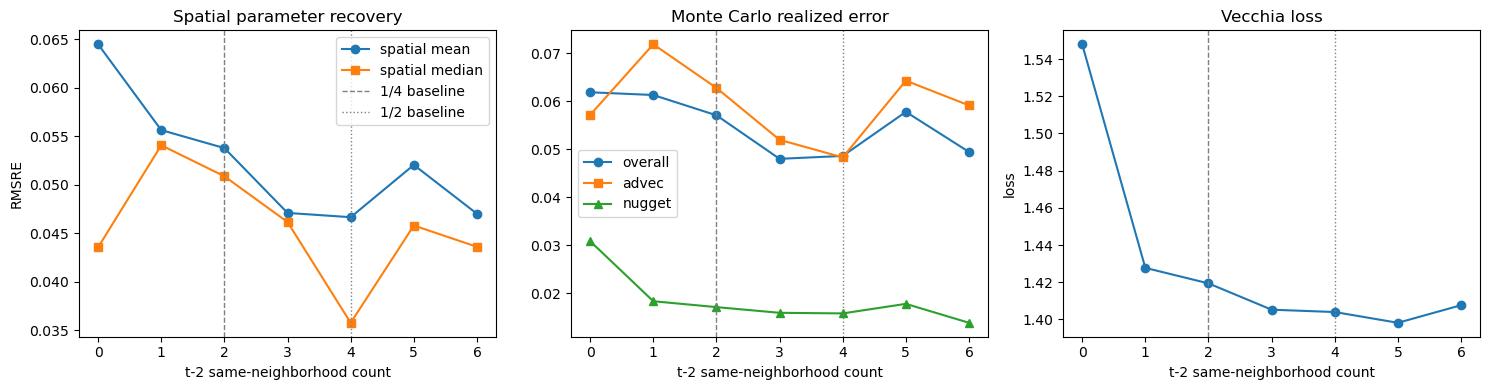

In [9]:
display(mc_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(mc_summary["lag2_nbs"], mc_summary["spatial_rmsre_mean"], marker="o", label="spatial mean")
axes[0].plot(mc_summary["lag2_nbs"], mc_summary["spatial_rmsre_median"], marker="s", label="spatial median")
axes[0].axvline(RATIO_BASELINE_C_QUARTER, color="gray", linestyle="--", linewidth=1, label="1/4 baseline")
axes[0].axvline(RATIO_BASELINE_C_HALF, color="gray", linestyle=":", linewidth=1, label="1/2 baseline")
axes[0].set_title("Spatial parameter recovery")
axes[0].set_xlabel("t-2 same-neighborhood count")
axes[0].set_ylabel("RMSRE")
axes[0].legend()

axes[1].plot(mc_summary["lag2_nbs"], mc_summary["overall_rmsre_mean"], marker="o", label="overall")
axes[1].plot(mc_summary["lag2_nbs"], mc_summary["advec_rmsre_mean"], marker="s", label="advec")
axes[1].plot(mc_summary["lag2_nbs"], mc_summary["nugget_re_mean"], marker="^", label="nugget")
axes[1].axvline(RATIO_BASELINE_C_QUARTER, color="gray", linestyle="--", linewidth=1)
axes[1].axvline(RATIO_BASELINE_C_HALF, color="gray", linestyle=":", linewidth=1)
axes[1].set_title("Monte Carlo realized error")
axes[1].set_xlabel("t-2 same-neighborhood count")
axes[1].legend()

axes[2].plot(mc_summary["lag2_nbs"], mc_summary["loss_mean"], marker="o")
axes[2].axvline(RATIO_BASELINE_C_QUARTER, color="gray", linestyle="--", linewidth=1)
axes[2].axvline(RATIO_BASELINE_C_HALF, color="gray", linestyle=":", linewidth=1)
axes[2].set_title("Vecchia loss")
axes[2].set_xlabel("t-2 same-neighborhood count")
axes[2].set_ylabel("loss")

plt.tight_layout()
plt.show()


## Focused Long Run

After the first-stage screen, reduce `FOCUSED_C_VALUES` to the best few candidates plus the quarter/half ratio baselines.


In [10]:
RUN_FOCUSED_MC = False
FOCUSED_C_VALUES = sorted(set([RATIO_BASELINE_C_QUARTER, RATIO_BASELINE_C_HALF, MAX_LAG2_NEIGHBORS]))
FOCUSED_MC_NUM_ITERS = 100
FOCUSED_SEED = 4242

if RUN_FOCUSED_MC:
    _old_specs = MODEL_SPECS
    try:
        MODEL_SPECS = make_lag2_realloc_specs(FOCUSED_C_VALUES)
        df_focused = run_experiment(
            num_iters=FOCUSED_MC_NUM_ITERS,
            seed=FOCUSED_SEED,
            compute_godambe=False,
            save_csv=True,
            csv_name="sim_vecchia_lag2_budget_realloc_focused_mc_042926_results.csv",
        )
        focused_summary = summarize_mc(df_focused)
        display(focused_summary.sort_values("spatial_rmsre_mean"))
    finally:
        MODEL_SPECS = _old_specs
else:
    df_focused = pd.DataFrame()
    focused_summary = pd.DataFrame()
    print("Skipping focused long run. Set RUN_FOCUSED_MC=True after the first-stage screen.")


Skipping focused long run. Set RUN_FOCUSED_MC=True after the first-stage screen.


## Interpretation

- This is the fair fixed-budget test: increasing `C` removes current-time extra spatial neighbors and reallocates those slots to `t-2`.
- If `C=2` wins or is competitive, the `rho_2=1/4` baseline is supported.
- If `C=4` wins, a `rho_2=1/2` second-lag retention ratio is more appropriate.
- If large `C` wins, second-lag local-neighborhood information is more valuable than extra current-time spatial neighbors.
- If small `C` wins, second-lag local-neighborhood slots saturate quickly and extra current-time spatial neighbors are more efficient.
